# Synthetic Gaussian-frailty grid pilot

Results for 4 target Kendall's tau values, 3 censoring rates, 3 latent dimensions, and 5 seeds (`n=10,000`, 10 features). DVFM results use prior prediction and the saved **best validation ELBO after warmup** checkpoint.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
ROOT = Path.cwd()
if not (ROOT / "results" / "synthetic-gaussian-frailty-grid-pilot").exists():
    ROOT = ROOT.parent
RESULTS = ROOT / "results" / "synthetic-gaussian-frailty-grid-pilot"
raw = pd.read_csv(RESULTS / "results_raw.csv")
diagnostics = pd.read_csv(RESULTS / "dvfm_diagnostics.csv")
CHECKPOINT = "best_validation_elbo_post_warmup"
dvfm = raw.query("model == 'dvfm' and checkpoint == @CHECKPOINT and prediction_mode == 'prior'").copy()
diag = diagnostics.query("checkpoint == @CHECKPOINT and subgroup == 'all'").copy()
print(f"Loaded {len(raw):,} result rows; analyzing {len(dvfm):,} DVFM rows.")

Loaded 960 result rows; analyzing 180 DVFM rows.


## Subject-level frailty recovery

Mean held-out Spearman correlation across five seeds. Recovery is undefined at tau 0 because frailty has zero outcome loading.

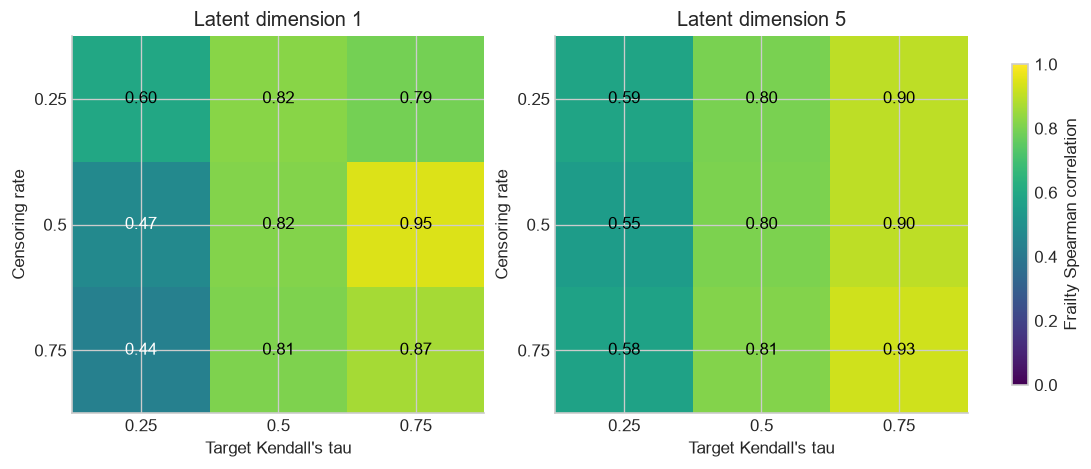

In [2]:
taus_positive = [0.25, 0.50, 0.75]
censoring_rates = [0.25, 0.50, 0.75]
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), constrained_layout=True)
for ax, latent_dim in zip(axes, [1, 5]):
    table = (diag.query("latent_dim == @latent_dim and frailty_recovery_defined == True")
             .pivot_table(index="target_censoring_rate", columns="target_kendall_tau",
                          values="frailty_spearman", aggfunc="mean")
             .reindex(index=censoring_rates, columns=taus_positive))
    image = ax.imshow(table, vmin=0, vmax=1, cmap="viridis", aspect="auto")
    for row in range(len(censoring_rates)):
        for col in range(len(taus_positive)):
            value = table.iloc[row, col]
            ax.text(col, row, f"{value:.2f}", ha="center", va="center",
                    color="white" if value < 0.55 else "black")
    ax.set(xticks=range(3), xticklabels=taus_positive, yticks=range(3),
           yticklabels=censoring_rates, xlabel="Target Kendall's tau",
           ylabel="Censoring rate", title=f"Latent dimension {latent_dim}")
fig.colorbar(image, ax=axes, label="Frailty Spearman correlation", shrink=0.85)
plt.show()

## Conditional dependence recovery

Each panel is a censoring regime. This separation is essential: averaging over censoring can make positive and negative errors cancel. The dashed line represents perfect recovery.

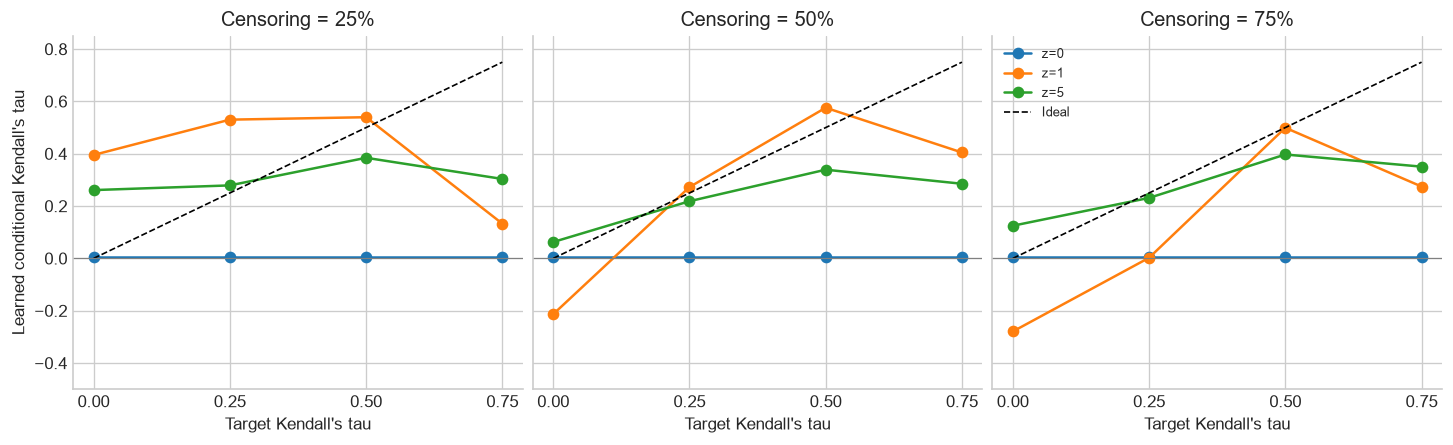

In [3]:
target_taus = [0.0, 0.25, 0.50, 0.75]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharex=True, sharey=True, constrained_layout=True)
for ax, censoring_rate in zip(axes, censoring_rates):
    subset = diag[diag["target_censoring_rate"] == censoring_rate]
    summary = subset.groupby(["latent_dim", "target_kendall_tau"])["learned_conditional_kendall_tau"].mean()
    for latent_dim in [0, 1, 5]:
        values = summary.loc[latent_dim].reindex(target_taus)
        ax.plot(target_taus, values, marker="o", label=f"z={latent_dim}")
    ax.plot(target_taus, target_taus, "--", color="black", linewidth=1, label="Ideal")
    ax.axhline(0, color="grey", linewidth=0.7)
    ax.set(title=f"Censoring = {censoring_rate:.0%}", xlabel="Target Kendall's tau",
           xticks=target_taus, ylim=(-0.5, 0.85))
axes[0].set_ylabel("Learned conditional Kendall's tau")
axes[-1].legend(frameon=False, fontsize=8, loc="upper left")
plt.show()

## Predictive performance

Oracle IBS is averaged over the three censoring regimes and five seeds for compactness. Lower is better; consult the underlying results before making censoring-specific claims.

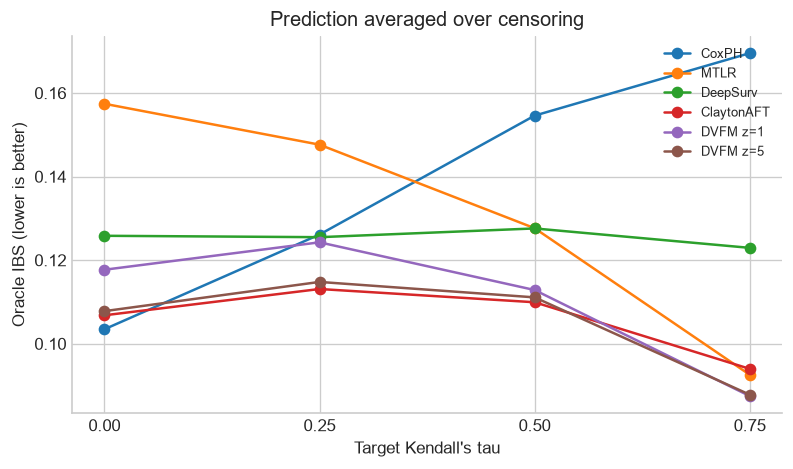

,Model,Oracle IBS (lower),Oracle CI (higher)
0,DVFM z=5,0.105 +/- 0.011,0.639 +/- 0.064
1,ClaytonAFT,0.106 +/- 0.008,0.643 +/- 0.065
2,DVFM z=1,0.111 +/- 0.016,0.637 +/- 0.064
3,DVFM z=0,0.118 +/- 0.017,0.636 +/- 0.059
4,DeepSurv,0.125 +/- 0.022,0.597 +/- 0.059
5,MTLR,0.131 +/- 0.032,0.575 +/- 0.057
6,CoxPH,0.138 +/- 0.051,0.644 +/- 0.063


In [6]:
baseline = raw[raw["model"].ne("dvfm")].copy()
baseline["label"] = baseline["model"].map({
    "coxph": "CoxPH", "clayton_aft": "ClaytonAFT",
    "deepsurv": "DeepSurv", "mtlr": "MTLR",
})
dvfm["label"] = dvfm["latent_dim"].map(lambda value: f"DVFM z={int(value)}")
comparison = pd.concat([baseline, dvfm], ignore_index=True)
fig, ax = plt.subplots(figsize=(6.5, 3.8), constrained_layout=True)
for label in ["CoxPH", "MTLR", "DeepSurv", "ClaytonAFT", "DVFM z=1", "DVFM z=5"]:
    values = comparison[comparison["label"] == label].groupby("target_kendall_tau")["oracle_ibs"].mean()
    ax.plot(values.index, values.values, marker="o", label=label)
ax.set(xlabel="Target Kendall's tau", ylabel="Oracle IBS (lower is better)",
       title="Prediction averaged over censoring", xticks=target_taus)
ax.legend(frameon=False, fontsize=8)
plt.show()

table = comparison.groupby("label").agg(
    ibs_mean=("oracle_ibs", "mean"), ibs_sd=("oracle_ibs", "std"),
    ci_mean=("oracle_ci", "mean"), ci_sd=("oracle_ci", "std"),
).reset_index()
table["Oracle IBS (lower)"] = table.apply(lambda row: f"{row.ibs_mean:.3f} +/- {row.ibs_sd:.3f}", axis=1)
table["Oracle CI (higher)"] = table.apply(lambda row: f"{row.ci_mean:.3f} +/- {row.ci_sd:.3f}", axis=1)
table[["label", "Oracle IBS (lower)", "Oracle CI (higher)"]].rename(
    columns={"label": "Model"}
).sort_values("Oracle IBS (lower)").reset_index(drop=True)

## Takeaway

Subject-level frailty recovery strengthens with dependence. Population dependence recovery is much less reliable: tau 0.50 is recovered consistently, while weak-dependence errors can cancel when averaged and tau 0.75 is underestimated. Predictively, DVFM is strongest under high dependent censoring but is not uniformly best under weak or absent dependence.